In [19]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


# Results: finding optimal solution w/ and w/out balance constraints

In [20]:
multirun_dir = 'multirun/2024-12-20/12-44-19'

# # create df of all results
# metric,value,std,category
# maximize,True,,config
# min_group_size,2,,config
# max_group_size,2,,config
# balance,0.99,,config
# theoretical_optimal_cost,391.94964595357305,,optimization
# gap_to_optimal_percent,0.11212143411773504,,optimization
# number_of_groups,98.0,,basic
# group_size_mean,2.0,0.0,basic
# group_size_min,2.0,,basic
# group_size_max,2.0,,basic
# within_group_variance,0.49875336425330913,0.3530124913662726,skill_diversity
# between_group_variance,0.0012466357466908958,0.0004619062262755038,skill_diversity
# sensitive_attr_0_population_mean,0.5,,fairness
# sensitive_attr_0_group_ratio_mean,0.5,0.0,fairness

df_rows = {
        'n_pairs': [],
        'balance': [],
        'seed': [],
        'convergence_time': [],
        'min_group_size': [],
        'max_group_size': [],
        'maximize': [],
        'theoretical_optimal_cost': [],
        'gap_to_optimal_percent': [],
        'number_of_groups': [],
        'group_size_mean': [],
        'group_size_min': [],
        'group_size_max': [],
        'mean_within_group_variance': [],
        'std_within_group_variance': [],
        'mean_between_group_variance': [],
        'std_between_group_variance': [],
        'sensitive_attr_0_population_mean': [],
        'sensitive_attr_0_group_ratio_mean': [],
        'sensitive_attr_0_group_ratio_std': []
        }

# convergence time == 'cumulative time' column of last row in loss_curve.csv where improvement is True
# 26,195.51018638951052,195.51018638951052,0.3777174949645996,9.776551008224487,True 


for root, dirs, files in os.walk(multirun_dir):
    
    root_info_added = False
    for file in files:
        if ('n_pairs' in root) and ('balance' in root) and ('seed' in root) and ('maximize' in root):
            if file.endswith('.csv'):
                n_pairs = int(root.split('n_pairs_')[1].split('/')[0])
                balance = float(root.split('balance_')[1].split('/')[0])
                seed = int(root.split('seed_')[1].split('/')[0])
                maximize = root.split('maximize_')[1].split('/')[0]
                if maximize == 'None':
                    convergence_time = 0.0
    
                if file == 'loss_curve.csv':
                    loss_curve = pd.read_csv(os.path.join(root, file))
                    last_row = loss_curve.iloc[-1]
                    convergence_time = last_row['cumulative_time']
                
                if file == 'stats.csv':
                    stats = pd.read_csv(os.path.join(root, file))
                    df_rows['min_group_size'].append(stats[stats['metric'] == 'min_group_size']['value'].values[0])
                    df_rows['max_group_size'].append(stats[stats['metric'] == 'max_group_size']['value'].values[0])
                    df_rows['theoretical_optimal_cost'].append(stats[stats['metric'] == 'theoretical_optimal_cost']['value'].values[0])
                    df_rows['gap_to_optimal_percent'].append(stats[stats['metric'] == 'gap_to_optimal_percent']['value'].values[0])
                    df_rows['number_of_groups'].append(stats[stats['metric'] == 'number_of_groups']['value'].values[0])
                    df_rows['group_size_mean'].append(stats[stats['metric'] == 'group_size_mean']['value'].values[0])
                    df_rows['group_size_min'].append(stats[stats['metric'] == 'group_size_min']['value'].values[0])
                    df_rows['group_size_max'].append(stats[stats['metric'] == 'group_size_max']['value'].values[0])
                    df_rows['mean_within_group_variance'].append(stats[stats['metric'] == 'within_group_variance']['value'].values[0])
                    df_rows['std_within_group_variance'].append(stats[stats['metric'] == 'within_group_variance']['std'].values[0])
                    df_rows['mean_between_group_variance'].append(stats[stats['metric'] == 'between_group_variance']['value'].values[0])
                    df_rows['std_between_group_variance'].append(stats[stats['metric'] == 'between_group_variance']['std'].values[0])
                    df_rows['sensitive_attr_0_population_mean'].append(stats[stats['metric'] == 'sensitive_attr_0_population_mean']['value'].values[0])
                    df_rows['sensitive_attr_0_group_ratio_mean'].append(stats[stats['metric'] == 'sensitive_attr_0_group_ratio_mean']['value'].values[0])
                    df_rows['sensitive_attr_0_group_ratio_std'].append(stats[stats['metric'] == 'sensitive_attr_0_group_ratio_mean']['std'].values[0])

                if not root_info_added:
                    df_rows['n_pairs'].append(n_pairs)
                    df_rows['balance'].append(balance)
                    df_rows['seed'].append(seed)
                    df_rows['convergence_time'].append(convergence_time)
                    df_rows['maximize'].append(maximize)
                    root_info_added = True

df = pd.DataFrame(df_rows)
df_maximize = df[df['maximize'] == 'True']
df_minimize = df[df['maximize'] == 'False']
df_random = df[df['maximize'] == 'None']
df_maximize = df_maximize.drop(columns=['maximize'])
df_minimize = df_minimize.drop(columns=['maximize'])
df_random = df_random.drop(columns=['maximize'])

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_experiment_boxplot(df, variable, balance, maximize, n_pairs, figsize=(10, 6)):
    """
    Create a boxplot for experimental results with individual points for different seeds.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the experimental results
    variable : str
        The name of the variable to plot (e.g., 'mean_within_group_variance')
    balance : float
        The balance value to filter by
    maximize : bool or str
        Whether to show results for maximize=True or False
    n_pairs : int
        The number of pairs to filter by
    figsize : tuple, optional
        The size of the figure (width, height)
        
    Returns:
    --------
    fig, ax : tuple
        The matplotlib figure and axis objects
    """
    # Filter the dataframe based on the parameters
    mask = (
        (df['balance'] == balance) & 
        (df['maximize'] == str(maximize)) & 
        (df['n_pairs'] == n_pairs)
    )
    filtered_df = df[mask]
    
    if filtered_df.empty:
        raise ValueError("No data found matching the specified criteria")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot with individual points
    sns.boxplot(y=filtered_df[variable], ax=ax, color='lightblue', width=0.5)
    sns.swarmplot(y=filtered_df[variable], ax=ax, color='navy', size=8, alpha=0.6)
    
    # Customize the plot
    ax.set_title(f'{variable} Distribution\n(balance={balance}, maximize={maximize}, n_pairs={n_pairs})')
    ax.set_ylabel(variable)
    
    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

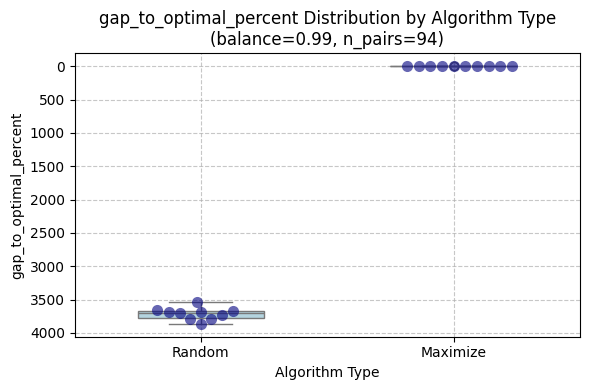

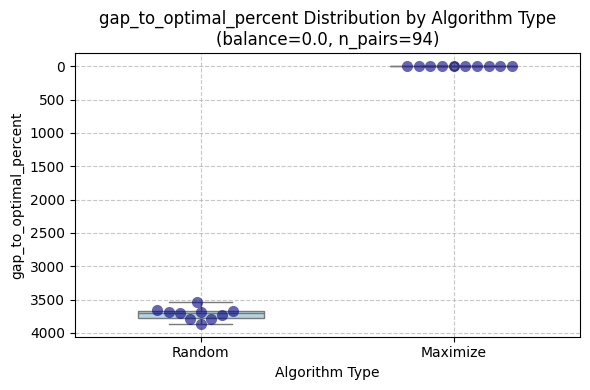

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_comparison_boxplots(df, variable, balance, n_pairs, figsize=(4, 2)):
    """
    Create side-by-side boxplots comparing maximize=False, None, and True conditions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the experimental results
    variable : str
        The name of the variable to plot (e.g., 'mean_within_group_variance')
    balance : float
        The balance value to filter by
    n_pairs : int
        The number of pairs to filter by
    figsize : tuple, optional
        The size of the figure (width, height)
        
    Returns:
    --------
    fig, ax : tuple
        The matplotlib figure and axis objects
    """
    # Filter the dataframe based on the parameters
    mask = (df['balance'] == balance) & (df['n_pairs'] == n_pairs)
    filtered_df = df[mask].copy()
    
    if filtered_df.empty:
        raise ValueError("No data found matching the specified criteria")
    
    # Create a more readable label for the maximize conditions
    maximize_labels = {
        # 'False': 'Minimize',
        'None': 'Random',
        'True': 'Maximize'
    }
    filtered_df['Algorithm'] = filtered_df['maximize'].map(maximize_labels)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot with individual points
    sns.boxplot(
        data=filtered_df,
        x='Algorithm',
        y=variable,
        order=['Random', 'Maximize'],
        ax=ax,
        color='lightblue',
        width=0.5
    )
    
    sns.swarmplot(
        data=filtered_df,
        x='Algorithm',
        y=variable,
        order=['Random', 'Maximize'],
        ax=ax,
        color='navy',
        size=8,
        alpha=0.6
    )
    
    # Customize the plot
    ax.set_title(f'{variable} Distribution by Algorithm Type\n(balance={balance}, n_pairs={n_pairs})')
    ax.set_ylabel(variable)
    ax.set_xlabel('Algorithm Type')
    
    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

fig, ax = plot_comparison_boxplots(
    df=df, 
    variable='gap_to_optimal_percent',
    balance=0.99,
    n_pairs=94,
    figsize=(6, 4)
)
plt.show()

fig, ax = plot_comparison_boxplots(
    df=df, 
    variable='gap_to_optimal_percent',
    balance=0.0,
    n_pairs=94,
    figsize=(6, 4)
)
plt.show()

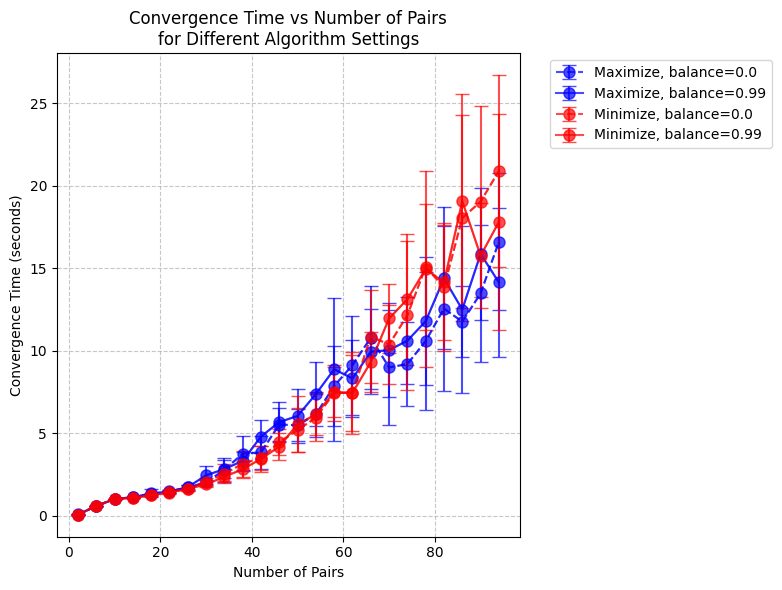

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_convergence_times(df, figsize=(12, 8)):
    """
    Plot convergence time vs n_pairs for different maximize and balance conditions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the experimental results
    figsize : tuple, optional
        The size of the figure (width, height)
        
    Returns:
    --------
    fig, ax : tuple
        The matplotlib figure and axis objects
    """
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Colors and markers for different conditions
    colors = {'True': 'blue', 'False': 'red'}
    linestyles = {0.0: '--', 0.99: '-'}
    conditions = [
        ('True', 0.0),
        ('True', 0.99),
        ('False', 0.0),
        ('False', 0.99)
    ]
    
    for maximize, balance in conditions:
        # Filter data for this condition
        mask = (df['maximize'] == maximize) & (df['balance'] == balance)
        condition_df = df[mask]
        
        # Group by n_pairs and calculate mean and std of convergence_time
        grouped = condition_df.groupby('n_pairs')['convergence_time'].agg(['mean', 'std']).reset_index()
        
        # Plot line and points with error bars
        label = f"{'Maximize' if maximize=='True' else 'Minimize'}, balance={balance}"
        ax.errorbar(grouped['n_pairs'], 
                   grouped['mean'], 
                   yerr=grouped['std'],
                   fmt='o',  # Just the marker
                   color=colors[maximize],
                   linestyle=linestyles[balance],
                   capsize=5,
                   capthick=1,
                   label=label,
                   markersize=8,
                   alpha=0.7)
        
        # Add connecting lines
        ax.plot(grouped['n_pairs'], 
                grouped['mean'], 
                color=colors[maximize],
                linestyle=linestyles[balance],
                alpha=0.5)
        
    # add the combinatorial algorithm baseline to the plot, scales as O(2^(N(N-1)/2)). Where 2^(N(N-1)/2) is the number of combinations to search, and we can do ~87500 combinations per second.
    # n_pairs = np.array(df['n_pairs'].unique().astype(int))
    # n_pairs = np.sort(n_pairs)
    # baseline_fn = lambda x: 1/87500 * 2**((x*2)*((x*2)-1)/2)
    # baseline = baseline_fn(n_pairs)
    # ax.plot(n_pairs, baseline, label='Combinatorial Baseline', color='black', linestyle='--', alpha=0.7)
    
    # Customize the plot
    ax.set_xlabel('Number of Pairs')
    ax.set_ylabel('Convergence Time (seconds)')
    ax.set_title('Convergence Time vs Number of Pairs\nfor Different Algorithm Settings')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # log scale for y-axis
    # ax.set_yscale('log')

    # set y axis lim to 10^-2
    # ax.set_ylim(0, 100)

    # Ensure all markers are visible
    plt.tight_layout()
    
    return fig, ax

# Example usage:
fig, ax = plot_convergence_times(df, figsize=(8, 6))
plt.show()

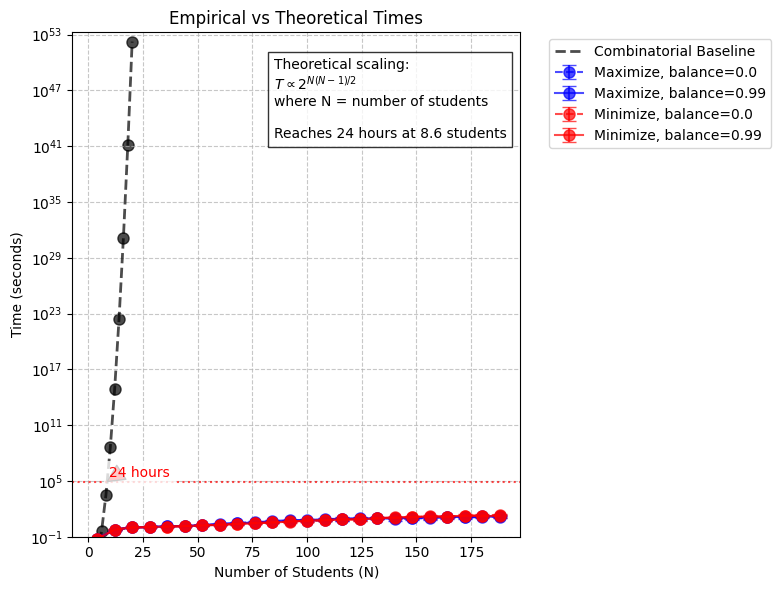

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_empirical_vs_theoretical(df, figsize=(12, 8)):
    """
    Create a single plot comparing empirical convergence times with theoretical scaling.
    Uses log scale to show both on the same plot.
    """
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Colors and conditions for empirical data
    colors = {'True': 'blue', 'False': 'red'}
    linestyles = {0.0: '--', 0.99: '-'}
    conditions = [
        ('True', 0.0),
        ('True', 0.99),
        ('False', 0.0),
        ('False', 0.99)
    ]
    
    # Plot empirical data
    for maximize, balance in conditions:
        # Filter data for this condition
        mask = (df['maximize'] == maximize) & (df['balance'] == balance)
        condition_df = df[mask]
        
        # Group by n_pairs and calculate mean and std of convergence_time
        grouped = condition_df.groupby('n_pairs')['convergence_time'].agg(['mean', 'std']).reset_index()
        grouped['N'] = grouped['n_pairs'] * 2
        
        # Plot line and points with error bars
        label = f"{'Maximize' if maximize=='True' else 'Minimize'}, balance={balance}"
        ax.errorbar(grouped['N'], 
                   grouped['mean'], 
                   yerr=grouped['std'],
                   fmt='o',
                   color=colors[maximize],
                   linestyle=linestyles[balance],
                   capsize=5,
                   capthick=1,
                   label=label,
                   markersize=8,
                   alpha=0.7)
        
        ax.plot(grouped['N'], 
               grouped['mean'], 
               color=colors[maximize],
               linestyle=linestyles[balance],
               alpha=0.5)
    
    # Add theoretical scaling
    N = np.arange(2, 21, 2)
    baseline_fn = lambda N: 1/87500 * 2**((N*(N-1))/2)
    baseline = baseline_fn(N)
    
    ax.semilogy(N, baseline, 'k--', label='Combinatorial Baseline', alpha=0.7, linewidth=2)
    ax.scatter(N, baseline, color='black', alpha=0.7, s=64)
    
    # Add 24-hour reference line
    one_day_seconds = 86400
    ax.axhline(y=one_day_seconds, color='r', linestyle=':', alpha=0.7)
    
    # Find intersection with 24-hour line
    N_fine = np.linspace(2, 20, 1000)
    baseline_fine = baseline_fn(N_fine)
    idx = np.argmin(np.abs(baseline_fine - one_day_seconds))
    intersection_x = N_fine[idx]
    
    # Add annotation for 24-hour line
    ax.annotate('24 hours', 
               xy=(intersection_x, one_day_seconds),
               xytext=(intersection_x + 1, one_day_seconds * 3),
               arrowprops=dict(facecolor='red', shrink=0.05),
               color='red',
               bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    
    # Customize plot
    ax.set_xlabel('Number of Students (N)')
    ax.set_ylabel('Time (seconds)')
    ax.set_title('Empirical vs Theoretical Times')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add text explaining the theoretical curve
    ax.text(0.45, 0.95, 
            'Theoretical scaling:\n$T \\propto 2^{N(N-1)/2}$\nwhere N = number of students\n\n' + 
            f'Reaches 24 hours at {intersection_x:.1f} students', 
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8))
    
    # Set y-axis limits to show full range
    ax.set_ylim(0.1, baseline.max() * 10)
    
    # Ensure all markers are visible
    plt.tight_layout()
    
    return fig, ax

# Example usage:
fig, ax = plot_empirical_vs_theoretical(df, figsize=(8, 6))
plt.show()

# Results: Diversity vs group sizes

In [44]:
import os

def run_sweep_analysis(base_dir):
    """
    Run analysis by reading parameters from directory structure
    """
    import os
    import pandas as pd
    import numpy as np
    
    df_rows = {
        'num_affinities': [],
        'group_size': [],
        'seed': [],
        'number_of_groups': [],
        'within_group_variance': [],
        'between_group_variance': [],
        # Distance metrics (from histogram)
        'mean_pairwise_distance': [],
        'std_pairwise_distance': [],
        'median_pairwise_distance': [],
    }

    # Walk through directory structure
    for root, dirs, files in os.walk(base_dir):
        if 'stats.csv' in files:  # Only process directories containing results
            # Extract parameters from path
            path_parts = root.split('/')
            
            # Find the relevant parts containing our parameters
            affinity_part = next((p for p in path_parts if p.startswith('affinty_')), None)
            size_part = next((p for p in path_parts if p.startswith('size_')), None)
            seed_part = next((p for p in path_parts if p.startswith('seed_')), None)
            
            if all([affinity_part, size_part, seed_part]):  # Only process if we have all parameters
                num_affinities = int(affinity_part.split('_')[1])
                group_size = int(size_part.split('_')[1])
                seed = int(seed_part.split('_')[1])
                
                # Load stats
                stats_df = pd.read_csv(os.path.join(root, 'stats.csv'))
                
                # Add basic parameters
                df_rows['num_affinities'].append(num_affinities)
                df_rows['group_size'].append(group_size)
                df_rows['seed'].append(seed)
                
                # Add metrics from stats.csv
                df_rows['number_of_groups'].append(
                    stats_df[stats_df['metric'] == 'number_of_groups']['value'].values[0]
                )
                df_rows['within_group_variance'].append(
                    stats_df[stats_df['metric'] == 'within_group_variance']['value'].values[0]
                )
                df_rows['between_group_variance'].append(
                    stats_df[stats_df['metric'] == 'between_group_variance']['value'].values[0]
                )
                
                # Load histogram data if it exists
                hist_path = os.path.join(root, 'histogram_data.npy')
                if os.path.exists(hist_path):
                    hist_data = np.load(hist_path, allow_pickle=True).item()
                    stats = hist_data['statistics']
                    df_rows['mean_pairwise_distance'].append(stats['mean'])
                    df_rows['std_pairwise_distance'].append(stats['std'])
                    df_rows['median_pairwise_distance'].append(stats['median'])
                else:
                    df_rows['mean_pairwise_distance'].append(np.nan)
                    df_rows['std_pairwise_distance'].append(np.nan)
                    df_rows['median_pairwise_distance'].append(np.nan)
                
    # Create DataFrame
    results_df = pd.DataFrame(df_rows)
    
    # Save results
    results_df.to_csv(os.path.join(base_dir, 'sweep_results.csv'), index=False)
    return results_df

def plot_sweep_summary(results_df, save_dir):
    """
    Create summary plots of the sweep results
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Group size vs metrics, colored by num_affinities
    metrics = ['within_group_variance', 'mean_pairwise_distance', 'min_affinity_representation']
    
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        for num_aff in sorted(results_df['num_affinities'].unique()):
            mask = results_df['num_affinities'] == num_aff
            mean_vals = results_df[mask].groupby('group_size')[metric].mean()
            std_vals = results_df[mask].groupby('group_size')[metric].std()
            
            plt.plot(mean_vals.index, mean_vals.values, 
                    label=f'{num_aff} affinities')
            plt.fill_between(mean_vals.index, 
                           mean_vals.values - std_vals.values,
                           mean_vals.values + std_vals.values,
                           alpha=0.2)
        
        plt.xlabel('Group Size')
        plt.ylabel(metric.replace('_', ' ').title())
        plt.legend()
        plt.savefig(os.path.join(save_dir, f'{metric}_vs_size.png'))
        plt.close()
    
    # 2. Heatmap of metrics vs group size and num_affinities
    for metric in metrics:
        mean_values = results_df.groupby(['num_affinities', 'group_size'])[metric].mean().unstack()
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(mean_values, cmap='viridis', annot=True, fmt='.2f')
        plt.title(f'{metric.replace("_", " ").title()} by Group Size and Affinities')
        plt.savefig(os.path.join(save_dir, f'{metric}_heatmap.png'))
        plt.close()

# Usage
base_dir = 'multirun/2025-01-27/14-32-39'
results_df = run_sweep_analysis(base_dir)
# plot_sweep_summary(results_df, base_dir)

In [45]:
def run_sweep_analysis(base_dir):
    """
    Run analysis by reading parameters from directory structure and save histogram data
    """
    import os
    import pandas as pd
    import numpy as np
    
    df_rows = {
        'num_affinities': [],
        'group_size': [],
        'seed': [],
        'number_of_groups': [],
        'within_group_variance': [],
        'between_group_variance': [],
        'mean_pairwise_distance': [],
        'std_pairwise_distance': [],
        'median_pairwise_distance': []
    }

    # Store histogram data separately
    histogram_data = {
        'params': [],  # Will store (num_affinities, group_size, seed) tuples
        'bin_edges': [],
        'counts': [],
        'raw_distances': []
    }

    # Walk through directory structure
    for root, dirs, files in os.walk(base_dir):
        if 'stats.csv' in files:
            # Extract parameters from path
            path_parts = root.split('/')
            affinity_part = next((p for p in path_parts if p.startswith('affinty_')), None)
            size_part = next((p for p in path_parts if p.startswith('size_')), None)
            seed_part = next((p for p in path_parts if p.startswith('seed_')), None)
            
            if all([affinity_part, size_part, seed_part]):
                num_affinities = int(affinity_part.split('_')[1])
                group_size = int(size_part.split('_')[1])
                seed = int(seed_part.split('_')[1])
                
                # Load stats
                stats_df = pd.read_csv(os.path.join(root, 'stats.csv'))
                
                # Add basic parameters
                df_rows['num_affinities'].append(num_affinities)
                df_rows['group_size'].append(group_size)
                df_rows['seed'].append(seed)
                
                # Add metrics from stats.csv
                df_rows['number_of_groups'].append(
                    stats_df[stats_df['metric'] == 'number_of_groups']['value'].values[0]
                )
                df_rows['within_group_variance'].append(
                    stats_df[stats_df['metric'] == 'within_group_variance']['value'].values[0]
                )
                df_rows['between_group_variance'].append(
                    stats_df[stats_df['metric'] == 'between_group_variance']['value'].values[0]
                )
                
                # Load histogram data if it exists
                hist_path = os.path.join(root, 'histogram_data.npy')
                if os.path.exists(hist_path):
                    hist_data = np.load(hist_path, allow_pickle=True).item()
                    stats = hist_data['statistics']
                    df_rows['mean_pairwise_distance'].append(stats['mean'])
                    df_rows['std_pairwise_distance'].append(stats['std'])
                    df_rows['median_pairwise_distance'].append(stats['median'])
                    
                    # Store full histogram data
                    histogram_data['params'].append((num_affinities, group_size, seed))
                    histogram_data['bin_edges'].append(hist_data['bin_edges'])
                    histogram_data['counts'].append(hist_data['counts'])
                    histogram_data['raw_distances'].append(hist_data['raw_distances'])
                else:
                    df_rows['mean_pairwise_distance'].append(np.nan)
                    df_rows['std_pairwise_distance'].append(np.nan)
                    df_rows['median_pairwise_distance'].append(np.nan)

    # Create DataFrame
    results_df = pd.DataFrame(df_rows)
    
    # Save results
    results_df.to_csv(os.path.join(base_dir, 'sweep_results.csv'), index=False)
    
    # Save histogram data
    np.save(os.path.join(base_dir, 'all_histogram_data.npy'), histogram_data)
    return results_df, histogram_data

results_df, histogram_data = run_sweep_analysis(base_dir)


In [46]:
def plot_distance_distributions(histogram_data, save_dir, cmap=plt.cm.Blues):
    """
    Plot KDE of pairwise distances and summary statistics (median and IQR)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    
    # Get unique parameter values
    params = np.array(histogram_data['params'])
    unique_affinities = np.unique(params[:, 0])
    unique_sizes = sorted(np.unique(params[:, 1]))
    
    # Create blue color gradient
    num_sizes = len(unique_sizes)
    blues = cmap(np.linspace(0.3, 0.9, num_sizes))
    
    # Plot for each affinity number
    for num_aff in unique_affinities:
        # Create figure with two subplots side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), 
                                      gridspec_kw={'width_ratios': [2, 1]})
        
        # Store summary statistics for right plot
        medians = []
        q1s = []
        q3s = []
        
        # Plot KDE for each group size
        for i, size in enumerate(unique_sizes):
            matches = [(i, p) for i, p in enumerate(params) 
                      if p[0] == num_aff and p[1] == size]
            
            if matches:
                # Combine raw distances for this configuration
                all_distances = []
                for idx, _ in matches:
                    all_distances.extend(histogram_data['raw_distances'][idx])
                
                # Store summary statistics
                medians.append(np.median(all_distances))
                q1s.append(np.percentile(all_distances, 25))
                q3s.append(np.percentile(all_distances, 75))
                
                # Calculate and plot KDE
                kde = stats.gaussian_kde(all_distances)
                x_range = np.linspace(min(all_distances), max(all_distances), 200)
                density = kde(x_range)
                
                ax1.plot(x_range, density, color=blues[i], 
                        label=f'Group Size {size}',
                        linewidth=2)
        
        # Configure left subplot (KDE)
        ax1.set_xlabel('Pairwise Distance in Eigenmap Space', fontsize=12)
        ax1.set_ylabel('Density', fontsize=12)
        ax1.set_title(f'Distance Distribution for {num_aff} Affinities', fontsize=14)
        ax1.grid(True, alpha=0.3)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
        # Configure right subplot (Summary statistics)
        ax2.errorbar(unique_sizes, medians, 
                    yerr=[np.array(medians)-np.array(q1s), 
                          np.array(q3s)-np.array(medians)],
                    fmt='o', color='black', capsize=5, markersize=8)
        ax2.set_xlabel('Group Size', fontsize=12)
        ax2.set_ylabel('Distance', fontsize=12)
        ax2.set_title('Median and IQR of Distances', fontsize=14)
        ax2.grid(True, alpha=0.3)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        
        # Add legend
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Adjust layout
        plt.tight_layout()
        
        # Save figure
        plt.savefig(os.path.join(save_dir, f'distance_distribution_aff_{num_aff}.png'), 
                    dpi=300, bbox_inches='tight')
        plt.close()

plot_distance_distributions(histogram_data, base_dir)

In [78]:
def analyze_affinity_representation(assignments_df, affinity_groups, num_affinities):
    """
    Analyze affinity representation within groups
    Returns whether majority of groups are under/well/over represented
    """
    groups = assignments_df.groupby('group')
    total_groups = len(groups)
    threshold = total_groups / 2  # Majority threshold
    
    # Counters for each condition
    under_rep_count = 0  # Missing affinities
    well_bal_count = 0   # One of each
    over_rep_count = 0   # Multiple of each
    
    for _, group_df in groups:
        # Get affinities in this group
        group_affinities = affinity_groups[group_df.index]
        unique, counts = np.unique(group_affinities, return_counts=True)
        
        if len(unique) < num_affinities:  # Missing some affinities
            under_rep_count += 1
        elif all(counts == 1):  # Exactly one of each
            well_bal_count += 1
        elif all(counts > 1):  # Multiple of each
            over_rep_count += 1
    
    # Determine majority condition
    under_represented = under_rep_count > threshold
    well_balanced = well_bal_count > threshold
    over_represented = over_rep_count > threshold
    
    return under_represented, well_balanced, over_represented

def plot_distance_panels(histogram_data, save_dir, cmap=plt.cm.Blues):
    """
    Create and save separate SVG files for each panel:
    1. KDE with colorbar
    2. Summary statistics with markers
    3. 3D eigenmap visualization
    """
    import matplotlib.pyplot as plt
    from scipy import stats
    import pandas as pd
    from mpl_toolkits.mplot3d import Axes3D
    
    params = np.array(histogram_data['params'])
    unique_affinities = np.unique(params[:, 0])
    unique_sizes = sorted(np.unique(params[:, 1]))
    num_sizes = len(unique_sizes)
    blues = cmap(np.linspace(0.3, 0.9, num_sizes))
    
    for num_aff in unique_affinities:
        # 1. KDE Plot with colorbar
        fig_kde, (ax_kde, cax) = plt.subplots(1, 2, figsize=(8, 6), 
                                             gridspec_kw={'width_ratios': [15, 1]})
        
        for i, size in enumerate(unique_sizes):
            matches = [(i, p) for i, p in enumerate(params) 
                      if p[0] == num_aff and p[1] == size]
            
            if matches:
                all_distances = []
                for idx, _ in matches:
                    all_distances.extend(histogram_data['raw_distances'][idx])
                
                kde = stats.gaussian_kde(all_distances)
                x_range = np.linspace(min(all_distances), max(all_distances), 200)
                density = kde(x_range)
                ax_kde.plot(x_range, density, color=blues[i], linewidth=2)
        
        ax_kde.set_xlabel('Pairwise Distance')
        ax_kde.set_ylabel('Density')
        ax_kde.set_title(f'Distance Distribution\nfor {num_aff} Affinities')
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, 
                                  norm=plt.Normalize(min(unique_sizes), max(unique_sizes)))
        plt.colorbar(sm, cax=cax, label='Group Size')
        
        plt.savefig(os.path.join(save_dir, f'kde_panel_aff_{num_aff}.svg'), 
                    format='svg', bbox_inches='tight')
        plt.close()
        
        # 2. Summary Statistics Plot
        fig_stats, ax_stats = plt.subplots(figsize=(6, 6))
        
        medians = []
        q1s = []
        q3s = []
        marker_colors = []
        marker_shapes = []
        
        for i, size in enumerate(unique_sizes):
            matches = [(i, p) for i, p in enumerate(params) 
                      if p[0] == num_aff and p[1] == size]
            
            if matches:
                all_distances = []
                first_match_idx, first_match_params = matches[0]
                config_path = os.path.join(save_dir, 
                                         f'affinty_{num_aff}',
                                         f'size_{size}',
                                         f'seed_{first_match_params[2]}')
                
                # Load data and analyze affinity representation
                affinity_groups = np.load(os.path.join(config_path, 'affinity_groups.npy'))
                assignments_df = pd.read_csv(os.path.join(config_path, 'group_assignments.csv'))
                
                for idx, _ in matches:
                    all_distances.extend(histogram_data['raw_distances'][idx])
                
                # Analyze affinity representation using the updated function
                under_represented, well_balanced, over_represented = analyze_affinity_representation(
                    assignments_df, affinity_groups, num_aff)
                
                # Determine marker properties
                if under_represented:
                    marker_colors.append('red')
                    marker_shapes.append('s')  # square - missing affinities
                elif well_balanced:
                    marker_colors.append('green')
                    marker_shapes.append('^')  # triangle - one of each
                elif over_represented:
                    marker_colors.append('orange')
                    marker_shapes.append('o')  # circle - multiple of each
                else:
                    marker_colors.append('orange')
                    marker_shapes.append('o')
                
                medians.append(np.median(all_distances))
                q1s.append(np.percentile(all_distances, 25))
                q3s.append(np.percentile(all_distances, 75))
        
        # Plot markers
        for i, (size, median) in enumerate(zip(unique_sizes, medians)):
            ax_stats.errorbar(size, median,
                            yerr=[[median-q1s[i]], [q3s[i]-median]],
                            fmt=marker_shapes[i], color=marker_colors[i],
                            capsize=5, markersize=10, markeredgecolor='black')
        
        # Add legend
        legend_elements = [
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='red',
                      label='Missing affinities', markersize=10, markeredgecolor='black'),
            plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='green',
                      label='Well represented', markersize=10, markeredgecolor='black'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
                      label='Multiple of each', markersize=10, markeredgecolor='black')
        ]
        ax_stats.legend(handles=legend_elements)
        
        ax_stats.set_xlabel('Group Size')
        ax_stats.set_ylabel('Pairwise Distance in\nEigenmap Space')
        ax_stats.set_title('Median and IQR of Distances')
        
        plt.savefig(os.path.join(save_dir, f'stats_panel_aff_{num_aff}.svg'), 
                    format='svg', bbox_inches='tight')
        plt.close()
        
        # 3. 3D Eigenmap Plot
        fig_map = plt.figure(figsize=(8, 8))
        ax_map = fig_map.add_subplot(111, projection='3d')
        
        # Load eigenmap
        eigenmap = np.load(os.path.join(config_path, 'data/eigenmap.npy'))
        
        # Plot points
        for i in range(num_aff):
            mask = affinity_groups == i
            ax_map.scatter(eigenmap[mask, 0], 
                         eigenmap[mask, 1], 
                         eigenmap[mask, 2],
                         c=[plt.cm.tab10(i/num_aff)],
                         label=f'Affinity {i}',
                         alpha=0.8)
        
        ax_map.set_xlabel('Dimension 1')
        ax_map.set_ylabel('Dimension 2')
        ax_map.set_zlabel('Dimension 3')
        ax_map.set_title('Eigenmap Space')
        ax_map.grid(False)
        ax_map.xaxis.pane.fill = False
        ax_map.yaxis.pane.fill = False
        ax_map.zaxis.pane.fill = False
        ax_map.xaxis.pane.set_edgecolor('lightgrey')
        ax_map.yaxis.pane.set_edgecolor('lightgrey')
        ax_map.zaxis.pane.set_edgecolor('lightgrey')
        ax_map.view_init(elev=20, azim=45)
        ax_map.legend()
        
        plt.savefig(os.path.join(save_dir, f'eigenmap_panel_aff_{num_aff}.svg'), 
                    format='svg', bbox_inches='tight')
        plt.close()

plot_distance_panels(histogram_data, base_dir)